# 🐻‍❄️ Polars

### Introduction

**Data analysis** in Python is often performed using Pandas, a well-established library known for its readability and ease of use.
However, as datasets **grow larger and computations become more complex**, Pandas can slow down: it typically uses a single CPU core and was not designed for large-scale, parallel data processing.

That’s where **Polars** comes in.
Polars is a newer DataFrame library built in Rust, designed to be fast, memory-efficient, and parallelized by default. It relies on the Apache Arrow columnar format, which allows it to handle operations more efficiently than traditional row-based processing.

This notebook explores what can we do with Polars, how Polars compares to Pandas, when it can be advantageous to use one over the other, and what trade-offs exist between readability, performance, and scalability.    






**Rust:** Rust is a modern, open-source systems programming language designed to provide high performance, memory safety, and error-free concurrency (source: https://rust-lang.org/)  
**Apache Arrow:** Open-source, multi-language platform for high-performance in-memory data processing. It defines a standardized, columnar memory format optimized for modern CPUs, enabling efficient analytics and vectorized computation. (source https://www.datacamp.com/es/tutorial/apache-arrow)


#### **Goal of this notebook**

To understand basics about how to use Polars. Since it's a Dataframe library for data analysis and manipulation, like Pandas, I’ll occasionally compare to it, not as a competition, but as a reference point for users familiar with traditional data manipulation in Python.

For this purpose I will use a public dataset from data.gov that reports obesity and nutrition indicators for Women, Infants, and Children (WIC).

Again, the goal is not to prove one library is “better,” but to understand:
- When to use each, depending on dataset size and task type.
- How much performance gain Polars provides in real-world operations.
- What new concepts (like Lazy API) Polars bring to data analysis.


#### **Notebook overview**

1) **Setup**:Import libraries and prepare environment.  
2) **Load & Inspect Data**: Read the same dataset using both Pandas and Polars.  
3) **Compare Read Performance**: Masure CSV loading speed.  
4) **Filtering & Grouping Comparison**: Test and time common operations.  
5) **Lazy API Demo**: Show how Polars optimizes a query pipeline.
6) **Conclusion**: Summarize what we learned.

### 1. Setup

In [448]:
#First, let's install polars

!pip install polars --upgrade

First, we have a dataset extracted from https://data.gov/. Specifically, it is the Nutrition, Physical Activity, and Obesity - Women, Infant, and Child (https://catalog.data.gov/dataset/nutrition-physical-activity-and-obesity-women-infant-and-child)

The description of the dataset is as follows: 

This dataset includes data on weight status for children aged 3 months to 4 years old from Women, Infant, and Children Participant and Program Characteristics (WIC-PC). This data is used for DNPAO's Data, Trends, and Maps database, which provides national and state specific data on obesity, nutrition, physical activity, and breastfeeding. For more information about WIC-PC visit https://www.fns.usda.gov/wic/national-survey-wic-participants.

In [583]:
# Import Polars and Pandas to compare

import pandas as pd
import polars as pl
import time
import matplotlib.pyplot as plt

### 2. Load and inspect data

Here we load the same dataset using both Pandas and Polars to make sure we’re starting from the same data.  
We’ll also take a quick look at the data to understand its structure.


In [157]:
#Bring the file

file_path = "Nutrition__Physical_Activity__and_Obesity_W_I_C.csv"


In [501]:
#Load data with and inspect

# with Pandas
# df_pd = pd.read_csv(file_path)

# with Polars
df_pl = pl.read_csv(file_path)


In [503]:
# Let's see how many rows and columns has this dataset

# with Pandas
# df_pd.shape

# with Polars
df_pl.shape

(12852, 31)

In [519]:
# Checking what type of data comes in the dataframe

# with Pandas
#df_pd.dtypes

# with Polars
df_pl.schema


Schema([('YearStart', Int64),
        ('YearEnd', Int64),
        ('LocationAbbr', String),
        ('LocationDesc', String),
        ('Datasource', String),
        ('Class', String),
        ('Topic', String),
        ('Question', String),
        ('Data_Value_Unit', String),
        ('Data_Value_Type', String),
        ('Data_Value', Float64),
        ('Data_Value_Alt', Float64),
        ('Data_Value_Footnote_Symbol', String),
        ('Data_Value_Footnote', String),
        ('Low_Confidence_Limit', Float64),
        ('High_Confidence_Limit ', Float64),
        ('Sample_Size', Int64),
        ('Total', String),
        ('Age(months)', String),
        ('Sex', String),
        ('Race/Ethnicity', String),
        ('GeoLocation', String),
        ('ClassID', String),
        ('TopicID', String),
        ('QuestionID', String),
        ('DataValueTypeID', String),
        ('LocationID', Int64),
        ('StratificationCategory1', String),
        ('Stratification1', String),
        ('S

In [521]:
# Checking the first 5 rows of the dataframe

# with Pandas
#df_pd.head(5)

# with Polars
df_pl.head(5)


YearStart,YearEnd,LocationAbbr,LocationDesc,Datasource,Class,Topic,Question,Data_Value_Unit,Data_Value_Type,Data_Value,Data_Value_Alt,Data_Value_Footnote_Symbol,Data_Value_Footnote,Low_Confidence_Limit,High_Confidence_Limit,Sample_Size,Total,Age(months),Sex,Race/Ethnicity,GeoLocation,ClassID,TopicID,QuestionID,DataValueTypeID,LocationID,StratificationCategory1,Stratification1,StratificationCategoryId1,StratificationID1
i64,i64,str,str,str,str,str,str,str,str,f64,f64,str,str,f64,f64,i64,str,str,str,str,str,str,str,str,str,i64,str,str,str,str
2008,2008,"""AL""","""Alabama""","""Women, Infants, and Children P…","""Obesity / Weight Status""","""Obesity / Weight Status""","""Percent of WIC toddlers who ha…",null,"""Value""",15.3,15.3,null,null,14.7,15.8,18219,null,"""24 - 35""",null,null,"""(32.84057112200048, -86.631860…","""OWS""","""OWS1""","""Q040""","""VALUE""",1,"""Age (months)""","""24 - 35""","""AGEMO""","""AGEMO2435"""
2008,2008,"""AL""","""Alabama""","""Women, Infants, and Children P…","""Obesity / Weight Status""","""Obesity / Weight Status""","""Percent of WIC toddlers who ha…",null,"""Value""",14.9,14.9,null,null,14.4,15.5,14796,null,"""36 - 47""",null,null,"""(32.84057112200048, -86.631860…","""OWS""","""OWS1""","""Q040""","""VALUE""",1,"""Age (months)""","""36 - 47""","""AGEMO""","""AGEMO3647"""
2008,2008,"""AL""","""Alabama""","""Women, Infants, and Children P…","""Obesity / Weight Status""","""Obesity / Weight Status""","""Percent of WIC toddlers who ha…",null,"""Value""",16.4,16.4,null,null,15.6,17.1,10272,null,"""48 - 59""",null,null,"""(32.84057112200048, -86.631860…","""OWS""","""OWS1""","""Q040""","""VALUE""",1,"""Age (months)""","""48 - 59""","""AGEMO""","""AGEMO4859"""
2008,2008,"""AL""","""Alabama""","""Women, Infants, and Children P…","""Obesity / Weight Status""","""Obesity / Weight Status""","""Percent of WIC toddlers who ha…",null,"""Value""",25.0,25.0,null,null,19.3,30.7,228,null,null,null,"""American Indian/Alaska Native""","""(32.84057112200048, -86.631860…","""OWS""","""OWS1""","""Q040""","""VALUE""",1,"""Race/Ethnicity""","""American Indian/Alaska Native""","""RACE""","""RACENAA"""
2008,2008,"""AL""","""Alabama""","""Women, Infants, and Children P…","""Obesity / Weight Status""","""Obesity / Weight Status""","""Percent of WIC toddlers who ha…",null,"""Value""",8.8,8.8,null,null,5.4,12.2,273,null,null,null,"""Asian/Pacific Islander""","""(32.84057112200048, -86.631860…","""OWS""","""OWS1""","""Q040""","""VALUE""",1,"""Race/Ethnicity""","""Asian/Pacific Islander""","""RACE""","""RACEAPI"""


⬆️ Both libraries display the same content, but Polars shows strings with quotes and includes data types next to the columns.  This is part of how Polars handles data internally through the **Apache Arrow** format, it keeps type information visible and strict, while Pandas focuses more on readability.


In [541]:
# Are there any null values? how many nulls per column? PANDAS
(df_pd.isna().sum()
     .sort_values(ascending=False)    # sort descending
     .head(10))                    # show the top 10 columns with most missing values


Data_Value_Unit               12852
Data_Value_Footnote           12473
Data_Value_Footnote_Symbol    12473
Total                         11718
Sex                           10584
Age(months)                    9072
Race/Ethnicity                 7182
Data_Value_Alt                  379
Sample_Size                     379
Low_Confidence_Limit            379
dtype: int64

In [551]:
# Are there any null values? how many nulls per column? POLARS
null_counts = (
    df_pl
    .select([pl.col(c).is_null().sum().alias(c) for c in df_pl.columns])  # count nulls per column
    .melt(variable_name="column", value_name="null_count")                # reshape to 2-column format
    .sort("null_count", descending=True)                                 # sort descending
    .head(10)                                                            # top 10
)

null_counts




/var/folders/w0/pnd9y36s1vx9kd4_5nhlt3mm0000gn/T/ipykernel_96684/362241271.py:5: DeprecationWarning: `DataFrame.melt` is deprecated; use `DataFrame.unpivot` instead, with `index` instead of `id_vars` and `on` instead of `value_vars`
  .melt(variable_name="column", value_name="null_count")                # reshape to 2-column format


column,null_count
str,u32
"""Data_Value_Unit""",12852
"""Data_Value_Footnote_Symbol""",12473
"""Data_Value_Footnote""",12473
"""Total""",11718
"""Sex""",10584
"""Age(months)""",9072
"""Race/Ethnicity""",7182
"""Data_Value""",379
"""Data_Value_Alt""",379


In Polars, operations are written using expressions instead of running step by step like in Pandas.
This means we describe what we want to calculate (e.g., the number of missing values per column) rather than executing each step immediately.

By using pl.col() inside a select(), Polars can plan and optimize all calculations before running them — making it faster and more efficient for large datasets

In [559]:
# Exploring the dataset Pandas

print("\nUnique stratification categories:")
print(df_pd["StratificationCategory1"].value_counts())          # see stratifications categories

print("\nUnique values for 'Sex' stratification:")
print(df_pd.loc[df_pd["StratificationCategory1"] == "Sex", "Stratification1"].value_counts())  # male/female split



Unique stratification categories:
StratificationCategory1
Race/Ethnicity    5670
Age (months)      3780
Sex               2268
Total             1134
Name: count, dtype: int64

Unique values for 'Sex' stratification:
Stratification1
Female    1134
Male      1134
Name: count, dtype: int64


In [581]:
# Exploring the dataset Polars

# Show how many records belong to each stratification category
print("\nUnique stratification categories:")
print(df_pl["StratificationCategory1"].value_counts())  # works fine in Polars, same idea as Pandas


# Show the Male/Female distribution only for the 'Sex' stratification
print("\nUnique values for 'Sex' stratification:")
print(
    df_pl.filter(pl.col("StratificationCategory1") == "Sex")["Stratification1"].value_counts()
)




Unique stratification categories:
shape: (4, 2)
┌─────────────────────────┬───────┐
│ StratificationCategory1 ┆ count │
│ ---                     ┆ ---   │
│ str                     ┆ u32   │
╞═════════════════════════╪═══════╡
│ Age (months)            ┆ 3780  │
│ Total                   ┆ 1134  │
│ Sex                     ┆ 2268  │
│ Race/Ethnicity          ┆ 5670  │
└─────────────────────────┴───────┘

Unique values for 'Sex' stratification:
shape: (2, 2)
┌─────────────────┬───────┐
│ Stratification1 ┆ count │
│ ---             ┆ ---   │
│ str             ┆ u32   │
╞═════════════════╪═══════╡
│ Female          ┆ 1134  │
│ Male            ┆ 1134  │
└─────────────────┴───────┘


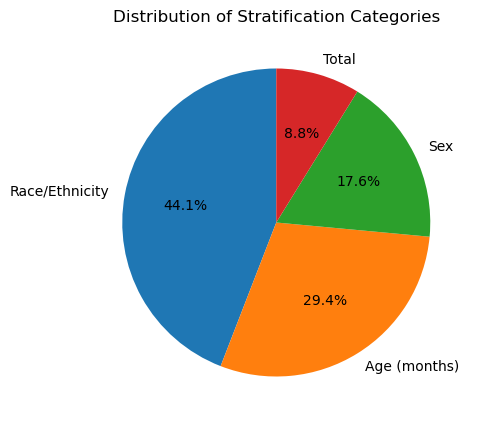

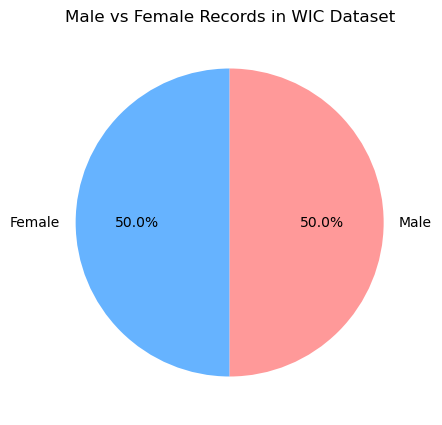

In [587]:
# What happen if we want to check this info in a chart?

# Polars was designed for data processing, not to create charts. Its focus is on speed, parallelization and optimization, not visuals.

# However, there are two suggested ways to create a chart from data processed with polars:
#1) Plotly + Polars
#2) Convert only what's necessary (what you're going to use) to Pandas and then use matplotlib or other.

# We are going to use nbr. 2, just for demonstration.
# Convert Polars data to Pandas just for plotting
df_plot = df_pl.to_pandas()

# --- Pie 1: Distribution of Stratification Categories ---
category_counts = df_plot["StratificationCategory1"].value_counts()

plt.figure(figsize=(5, 5))
plt.pie(category_counts, labels=category_counts.index, autopct='%1.1f%%', startangle=90)
plt.title("Distribution of Stratification Categories")
plt.show()

# --- Pie 2: Male vs Female Distribution (within 'Sex' stratification) ---
sex_counts = (
    df_plot[df_plot["StratificationCategory1"] == "Sex"]["Stratification1"]
    .value_counts()
)

plt.figure(figsize=(5, 5))
plt.pie(sex_counts, labels=sex_counts.index, autopct='%1.1f%%', colors=['#66b3ff', '#ff9999'], startangle=90)
plt.title("Male vs Female Records in WIC Dataset")
plt.show()


⬆️ The dataset is divided into four main stratification groups:

-  Race/Ethnicity: largest portion (5670 rows)  
-  Age (months): 2nd largest (3780)  
-  Sex: 2268 rows (split male/female)  

Total: 1134 overall averages

Each state and year has multiple rows, one per stratification group — so when aggregating or plotting, you’ll need to specify which group you want to analyze.

✅ Conclusion: this gives you flexibility — you can study obesity % by race, by age, by sex, or look at total

⬆️ The first three fields (Data_Value_Unit, Footnote, and Footnote_Symbol) are basically metadata columns — many missing values are normal because those are only filled for special notes or exceptions.

The columns Sex, Age (months), Race/Ethnicity, and Total appear here because only one of them applies per record, depending on the “StratificationCategory”.

Example: one row might refer to Sex = Female, another to Age (months) = 36–47, etc.

So the missing values are not “bad data”...they just reflect that each row belongs to one group.

The dataset is clean enough to use; missing values are structural, not errors.

In [601]:
# Explore stratification details with Pandas
print("\nUnique stratification categories (column StratificationCategory1):")
print(df_pd["StratificationCategory1"].value_counts())

# Count how many unique labels each category has
print("\nNumber of unique labels per stratification category:")
for cat in df_pd["StratificationCategory1"].unique():
    subset = df_pd[df_pd["StratificationCategory1"] == cat]
    print(f"{cat}: {subset['Stratification1'].nunique()} unique values")

# Preview which labels exist in each category
print("\nExample values per category:")
for cat in df_pd["StratificationCategory1"].unique():
    subset = df_pd[df_pd["StratificationCategory1"] == cat]
    print(f"\n{cat} → {subset['Stratification1'].unique()[:5]}")




Unique stratification categories (column StratificationCategory1):
StratificationCategory1
Race/Ethnicity    5670
Age (months)      3780
Sex               2268
Total             1134
Name: count, dtype: int64

Number of unique labels per stratification category:
Age (months): 7 unique values
Race/Ethnicity: 5 unique values
Sex: 2 unique values
Total: 1 unique values

Example values per category:

Age (months) → ['24 - 35' '36 - 47' '48 - 59' '12 - 17' '18 - 23']

Race/Ethnicity → ['American Indian/Alaska Native' 'Asian/Pacific Islander' 'Hispanic'
 'Non-Hispanic Black' 'Non-Hispanic White']

Sex → ['Female' 'Male']

Total → ['Total']


In [607]:
# Explore stratification details with Polars
print("\nUnique stratification categories (StratificationCategory1):")
print(df_pl["StratificationCategory1"].value_counts())

# Count how many unique labels each category has
print("\nNumber of unique labels per stratification category:")
cats = df_pl["StratificationCategory1"].unique().to_list()   # get list of all categories

for cat in cats:
    n_unique = (
        df_pl.filter(pl.col("StratificationCategory1") == cat)
             .select(pl.col("Stratification1").n_unique())
             .item()
    )
    print(f"{cat}: {n_unique} unique values")

# Preview which labels exist in each category
print("\nExample values per category:")
for cat in cats:
    labels = (
        df_pl.filter(pl.col("StratificationCategory1") == cat)
             .select(pl.col("Stratification1").unique())
             .to_series()
             .to_list()[:5]
    )
    print(f"\n{cat} → {labels}")



Unique stratification categories (StratificationCategory1):
shape: (4, 2)
┌─────────────────────────┬───────┐
│ StratificationCategory1 ┆ count │
│ ---                     ┆ ---   │
│ str                     ┆ u32   │
╞═════════════════════════╪═══════╡
│ Total                   ┆ 1134  │
│ Age (months)            ┆ 3780  │
│ Sex                     ┆ 2268  │
│ Race/Ethnicity          ┆ 5670  │
└─────────────────────────┴───────┘

Number of unique labels per stratification category:
Sex: 2 unique values
Race/Ethnicity: 5 unique values
Total: 1 unique values
Age (months): 7 unique values

Example values per category:

Sex → ['Female', 'Male']

Race/Ethnicity → ['Hispanic', 'Asian/Pacific Islander', 'American Indian/Alaska Native', 'Non-Hispanic White', 'Non-Hispanic Black']

Total → ['Total']

Age (months) → ['3 - 5', '24 - 35', '18 - 23', '36 - 47', '12 - 17']


⬆️ This part looks a bit longer than in Pandas because Polars works in a more explicit way.
It doesn’t assume what you want to do — you have to tell it clearly.

In Pandas, unique() gives you a simple list right away.
In Polars, it gives a special Polars object, so we add .to_list() to turn it into a normal Python list.

In Pandas, nunique() gives you a number directly.
In Polars, we also need .item() to extract that number from its internal format.

So yes, it takes one or two extra steps — but that’s because Polars is built for speed and precision with very large datasets.
It’s just being a bit more strict about what happens in each line

In [610]:
# Years are available in the dataset
years_available = df_pl["YearEnd"].unique()   # get all distinct years
print((years_available))


shape: (7,)
Series: 'YearEnd' [i64]
[
	2008
	2010
	2012
	2014
	2016
	2018
	2020
]


In [591]:
latest_year = df_pl["YearEnd"].max()
print(latest_year)

2020


### 3. Compare read performance

What we’re doing here?

We’ll check how long it takes Pandas and Polars to **load the exact same CSV file.**  
The goal isn’t to show one is “better,” but to illustrate how Polars impacts speed.  
We’ll use **time** library to measure execution in seconds, then calculate the ratio of speed.

In [619]:
# Let's compare CSV read times for Pandas and Polars

import time                     # already imported before, reused for timing

# Step 1: measure Pandas read time
start = time.time()             # start timer
df_pd = pd.read_csv(file_path)  # reload CSV using Pandas
pandas_time = time.time() - start   # stop timer and compute elapsed time

# Step 2: measure Polars read time
start = time.time()             # restart timer
df_pl = pl.read_csv(file_path)  # load the same file using Polars
polars_time = time.time() - start   # stop timer and compute elapsed time

# Step 3: print results side by side
print(f"Pandas read time: {pandas_time:.4f} seconds")
print(f"Polars read time: {polars_time:.4f} seconds")

# Step 4: optional ratio — how many times faster Polars was
if polars_time > 0:
    print(f"⚡ Polars was about {pandas_time / polars_time:.2f}× faster.")



Pandas read time: 0.0555 seconds
Polars read time: 0.0101 seconds
⚡ Polars was about 5.48× faster.


⬆️ Two lines of output: one for Pandas time, one for Polars time.  

Polars is faster...often 2–10× depending on machine & file size.  

This quick test shows why Polars is appealing for larger datasets — it uses multiple CPU cores automatically, while Pandas runs on one

Note: Polars is designed for speed and efficiency, especially when working with large datasets, let's say millions of rows (usually 1 million +).
It uses multi-threading and runs operations in parallel, which means it can handle different parts of the data at the same time.
That’s what makes it much faster than Pandas when the workload is big.

However, when your dataset is small or medium-sized (under a few hundred thousand rows or just a few megabytes) the performance difference often disappears.

In some cases, Pandas can even be a bit faster, simply because it has less startup overhead: Polars spends extra time optimizing before running the operation, which only pays off with larger data.

So, the recommendation is:

- Use Polars: when you’re working with big, heavy, or complex datasets that need to be processed efficiently.
- Use Pandas: when your data is lightweight and readability or simplicity matter more than speed.

Polars isn’t “slow” with small data, it’s just optimized for scale, not for tiny examples

### 4) Filtering & Grouping comparison 

#### 4.1  Filtering the dataset – **Pandas**

Before comparing how Pandas and Polars handle grouping,  
we first isolate the portion of the WIC dataset that’s relevant for our analysis.

In this step we:

- Select only the most recent year available (`YearEnd == 2020`).  
- Keep records where the stratification category is `"Sex"`.  
- Filter to include only `"Female"` entries.  
- Select two columns: `"LocationAbbr"` (state abbreviation) and `"Data_Value"`  
  (the percentage of WIC toddlers who are overweight).

This filtered subset will be the base for the next step,  
where we’ll aggregate and compare average overweight percentages by state.


In [403]:
# Select only the most recent year available 

df_filtered = df_pd[df_pd["YearEnd"] == latest_year]

# Keep only rows where the stratification category is 'Sex'
df_filtered = df_filtered[df_filtered["StratificationCategory1"] == "Sex"]

# Focus only on records where the stratification value is 'Female'
df_filtered = df_filtered[df_filtered["Stratification1"] == "Female"]

# Keep just the relevant columns for our analysis
df_filtered = df_filtered[["LocationAbbr", "Data_Value"]]

print(f"Filtered dataset shape: {df_filtered.shape}")  # show how many rows/columns remain
df_filtered.head(10)                                  # preview first 10 rows


Filtered dataset shape: (162, 2)


,LocationAbbr,Data_Value
11021,AL,15.4
11032,AK,18.1
11043,AZ,15.7
11054,AR,15.1
11065,CA,15.9
11076,CO,14.5
11087,CT,15.7
11098,DE,18.8
11109,DC,13.7
11120,FL,15.2


⬆️ This code selected only two relevant columns:

-  LocationAbbr → the state abbreviation (e.g., AL, AK, CA…).  
-  Data_Value → the percentage of female WIC toddlers who are overweight.

This filtered subset will be the base for the next step, where we’ll compare how Pandas and Polars handle grouping and aggregation

#### 4.2  Grouping & Aggregating with **Pandas** 

Now that we’ve filtered the dataset to include only female participants for the most recent year,
we’ll group the data by state (LocationAbbr) and calculate the average overweight percentage (Data_Value) for each.

This helps us understand which states have higher or lower averages among WIC female toddlers

In [331]:
# Grouping & Aggregating with Pandas

# 1️⃣ Group by state abbreviation (LocationAbbr)
# 2️⃣ Compute the mean Data_Value per group
# 3️⃣ Reset index so the result becomes a clean DataFrame
# 4️⃣ Sort states from highest to lowest average overweight percentage

df_grouped = (
    df_filtered
    .groupby("LocationAbbr")["Data_Value"]
    .mean()
    .reset_index()
    .sort_values("Data_Value", ascending=False)
)

# Display the top 10 states with the highest average overweight percentage
print("Average overweight percentage by state (top 10):")
df_grouped.head(10)


Average overweight percentage by state (top 10):


,LocationAbbr,Data_Value
0,AK,16.733333
8,DE,16.533333
20,MA,15.766667
43,SD,15.566667
4,CA,15.500000
18,KY,15.400000
21,MD,15.366667
41,RI,15.333333
45,TX,15.200000
31,NH,15.100000


⬆️ The table above shows the top 10 U.S. states with the highest average percentage of overweight WIC female toddlers in the most recent year (2020).

Alaska (AK) ranks first, with an average value of 16.7%, followed by Delaware (DE) and Massachusetts (MA).

**These numbers represent the average percentage of overweight female toddlers participating in the WIC program in each state.**

The left-most column (0, 8, 20, …) is simply the row index automatically added by Pandas — it doesn’t correspond to a variable in the dataset.

In the next step, we’ll perform the same grouping operation using Polars to compare both execution time and output consistency

#### 4.3  Grouping & Aggregating with **Polars** 

Now that we’ve filtered the dataset to include only female participants for the most recent year,
we’ll group the data by state (LocationAbbr) and calculate the average overweight percentage (Data_Value) for each.

This helps us understand which states have higher or lower averages among WIC female toddlers

In [362]:
# Grouping & Aggregating with **Polars**

# Select only the most recent year available 
  # compute the max YearStart and extract the scalar
df_pl_latest = df_pl.filter(pl.col("YearEnd") == latest_year_pl) # keep rows where YearStart equals the latest year

# Keep only rows where the stratification category is 'Sex'
df_pl_sex = df_pl_latest.filter(pl.col("StratificationCategory1") == "Sex")  # limit to records stratified by Sex

# Focus only on records where the stratification value is 'Female'
df_pl_female = df_pl_sex.filter(pl.col("Stratification1") == "Female")       # keep Female rows

# Keep just the relevant columns for our analysis
df_pl_filtered_native = df_pl_female.select(["LocationAbbr", "Data_Value"])  # state code + percentage value

print(f"Filtered dataset shape: {df_pl_filtered_native.shape}")  # show how many rows/columns remain
df_pl_filtered_native.head(10)                                  # preview first 10 rows



Filtered dataset shape: (162, 2)


LocationAbbr,Data_Value
str,f64
"""AL""",15.4
"""AK""",18.1
"""AZ""",15.7
"""AR""",15.1
"""CA""",15.9
"""CO""",14.5
"""CT""",15.7
"""DE""",18.8
"""DC""",13.7


In [401]:
# Group by state and compute the average overweight percentage
pl_state_avg_native = (
    df_pl_filtered_native
    .group_by("LocationAbbr")                                 # group by state
    .agg(pl.col("Data_Value").mean().alias("avg_overweight")) # mean of Data_Value per state
    .sort("avg_overweight", descending=True)                  # highest to lowest
)

# Quick peek at the first 10 rows
pl_state_avg_native.head(10)
 

LocationAbbr,avg_overweight
str,f64
"""AK""",16.733333
"""DE""",16.533333
"""MA""",15.766667
"""SD""",15.566667
"""CA""",15.5
"""KY""",15.4
"""MD""",15.366667
"""RI""",15.333333
"""TX""",15.2


Key Takeaways: Polars vs Pandas

-  **Same logic, different style:** Both libraries apply the same sequence, filter by year, stratification, and gender, then select key columns. The difference lies in the syntax: Polars uses chained methods and column expressions (pl.col()), while Pandas reads more imperatively.

- **Consistency in results:** Both produce the same filtered dataset: states with the percentage of overweight female toddlers for the most recent year (2020).

- **Efficiency edge:** Polars executes these steps faster because it’s multi-threaded and built on Apache Arrow, meaning it can process multiple parts of the data in parallel.

- **Clarity and safety:** Polars forces you to reference columns explicitly, reducing silent errors and making the transformation pipeline more transparent.

Overall, the analysis output is identical, but Polars achieves it more efficiently and with cleaner, more reproducible syntax.

### 5) Lazy API demo

What is “Lazy” in Polars context?

Normally, when you write df.filter(...).group_by(...).agg(...) in Polars, it runs everything immediately, that’s called **eager execution**.
But with **lazy mode**, Polars doesn’t run anything yet. Instead, it builds a plan, like a recipe, and then runs it all at once, optimized.

This lets Polars:

-  Combine filters before reading the data (so it reads less).
-  Avoid creating temporary DataFrames in memory.
-  Use multiple CPU cores automatically.
-  Decide the best order to execute operations.

It’s like telling Polars: Here’s what I want, you figure out the fastest way to do it.

**Eager mode**
- Works like Pandas: each operation runs immediately (e.g., filter(), group_by(), agg()).  
- Best for quick data exploration, debugging, or small datasets that fit easily in memory.
- Great when you want to check intermediate results at every step.

**Lazy mode**
- Instead of running commands instantly, Polars builds a logical plan first — like writing a recipe before cooking.
- When you call .collect(), Polars runs everything at once, optimized.
- Ideal for large datasets or complex transformations (with many filters, joins, or aggregations).
- It automatically:
-   Pushes filters down before reading the file (so it reads less data).
-   Uses multi-threading to parallelize work across CPU cores.
-   Eliminates temporary dataframes that Eager mode would create


Lazy execution doesn’t change what you compute, it changes how efficiently it’s done. It’s like the difference between following each step as you think of it (Eager) versus planning the full recipe and cooking once (Lazy)

In [635]:
# Step 5 — Lazy API demo: optimized query planning

# Start a lazy scan (doesn't load data yet, just references it)
lazy_df = pl.scan_csv(file_path)  

# Build the same pipeline as before — but in lazy mode
lazy_pipeline = (
    lazy_df
    .filter(pl.col("YearEnd") == 2020)                    # keep only 2020
    .filter(pl.col("StratificationCategory1") == "Sex")   # keep stratification by Sex
    .filter(pl.col("Stratification1") == "Female")        # keep only Female
    .group_by("LocationAbbr")                             # group by state
    .agg(pl.col("Data_Value").mean().alias("avg_overweight"))  # average % overweight
    .sort("avg_overweight", descending=True)              # sort top to bottom
)

# Explain plan — shows how Polars will optimize the steps before running
lazy_pipeline.explain()


'SORT BY [descending: [true]] [col("avg_overweight")]\n  AGGREGATE[maintain_order: false]\n    [col("Data_Value").mean().alias("avg_overweight")] BY [col("LocationAbbr")]\n    FROM\n    Csv SCAN [Nutrition__Physical_Activity__and_Obesity_W_I_C.csv]\n    PROJECT 5/31 COLUMNS\n    SELECTION: [([([(col("YearEnd")) == (2020)]) & ([(col("Stratification1")) == ("Female")])]) & ([(col("StratificationCategory1")) == ("Sex")])]\n    ESTIMATED ROWS: 12486'

In [433]:
# Actually execute the optimized plan
start_lazy = time.time()
result_lazy = lazy_pipeline.collect()   # now Polars runs everything
end_lazy = time.time()

# Print time and first few rows
print(f"Lazy query execution time: {end_lazy - start_lazy:.4f} seconds")
result_lazy.head(10)


Lazy query execution time: 0.1053 seconds


LocationAbbr,avg_overweight
str,f64
"""AK""",16.733333
"""DE""",16.533333
"""MA""",15.766667
"""SD""",15.566667
"""CA""",15.5
"""KY""",15.4
"""MD""",15.366667
"""RI""",15.333333
"""TX""",15.2


In [628]:
# Measure Pandas pipeline execution
start_pd = time.time()
_ = (
    df_pd[df_pd["YearEnd"] == 2020]
      .query('StratificationCategory1 == "Sex" and Stratification1 == "Female"')
      .groupby("LocationAbbr")["Data_Value"].mean()
)
t_pandas = time.time() - start_pd

# Measure Polars eager pipeline
start_pl = time.time()
_ = (
    df_pl
      .filter(pl.col("YearEnd") == 2020)
      .filter(pl.col("StratificationCategory1") == "Sex")
      .filter(pl.col("Stratification1") == "Female")
      .group_by("LocationAbbr")
      .agg(pl.col("Data_Value").mean().alias("avg_overweight"))
)
t_polars = time.time() - start_pl

# Measure Lazy pipeline
start_lazy = time.time()
_ = lazy_pipeline.collect()
t_lazy = time.time() - start_lazy

# Print results
print(f"Pandas exec time: {t_pandas:.4f} s")
print(f"Polars eager exec time: {t_polars:.4f} s")
print(f"Polars lazy exec time: {t_lazy:.4f} s")


Pandas exec time: 0.0138 s
Polars eager exec time: 0.0062 s
Polars lazy exec time: 0.0057 s


Execution time comparison (Pandas vs. Polars Eager vs. Polars Lazy)

We ran the same analysis pipeline using three modes:

-  Pandas (standard): executes each step in sequence.
-  Polars Eager: faster, multi-threaded, reads only the required columns.
-  Polars Lazy: builds and optimizes the full query before running once.

In most cases, Lazy Polars performs the best or matches Eager Polars with large datasets, since it avoids redundant steps and optimizes memory

### 6) Conclusion

The goal of this notebook was to learn about Polars and compare Pandas and Polars, not to prove one is “better,” but to understand trade-offs and use cases.

**Main findings:**
-  Pandas is great for small-to-medium datasets and interactive exploration.
-  Polars loads data much faster thanks to parallelization and Apache Arrow.
-  The syntax is different: Polars uses expressions (pl.col()) and method chaining.
-  Lazy API provides additional optimization for complex or heavy pipelines.

**Performance reflection:**
-  In our dataset (≈ 12 k rows), the differences were small, but for multi-GB files, Polars scales significantly better in both memory and time.

**Practical takeaway:**
-  Use Pandas when clarity and debugging matter.
-  Use Polars (Eager) when speed and efficiency start to matter.
-  Use Polars Lazy when working with large pipelines or when combining multiple transformations before output.

Polars doesn’t replace Pandas. The best choice depends on context, dataset size, and performance needs.